## Generating Model Ensemble Absorption Line Profiles with OutLines

If `OutLines` is not installed, this can be done using `pip install SpecOutLines` in terminal or directly below. Using `pip` will automatically handle any dependencies. Detailed documentation is available at https://github.com/sflury/OutLines

In [1]:
%pip install SpecOutLines

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already satisfied.
Requirement scipy already satisfied.
Requirement matplotlib already satisfied.


Start by importing the `OutLines` code and related basic packages.

In [2]:
import OutLines as OL
import numpy as np
import matplotlib.pyplot as plt

Here is an example where the terminal velocity of the wind is updated iteratively and plotted.

   --------------------------------------
  |           MODEL PARAMETERS           |
   --------------------------------------
  |   TerminalVelocity :   7000.000 km/s |
  |      VelocityIndex :      0.500      |
  |  LogColumnOutflow1 :     17.000      |
  |  LogColumnOutflow2 :     17.000      |
  |          DecayRate :      0.500      |
  |         PulseWidth :      0.100      |
  |      PulseInterval :      1.000      |
  |           InitPeak :      2.000      |
   --------------------------------------


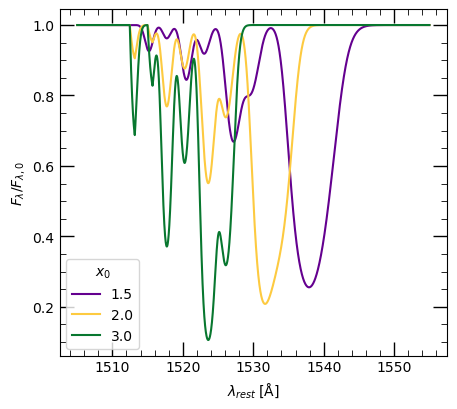

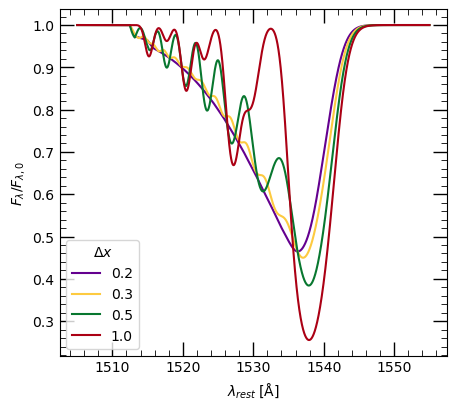

In [9]:
wave = np.array([1548.204,1550.784])
fosc = np.array([0.19,0.0952])
model = OL.Absorption(wave,fosc,VelocityField='VelPlaw',DensityProfile='DampedPulses')
model.update_params(['TerminalVelocity','VelocityIndex','DecayRate'],[7000,0.5,0.5])
model.update_params(['PulseWidth'],[0.1])
model.update_params(['LogColumnOutflow1','LogColumnOutflow2'],[17,17])
w = np.linspace(1505,1555,5001)
model.print_params()
for peak in [1.5,2,3]:
    model.update_params(['InitPeak'],[peak])
    plt.plot(w,model.get_profile(w),label=f'{peak:.1f}')
plt.xlabel(r'$\lambda_{rest}\rm\:[\AA]$')
plt.ylabel(r'$F_\lambda/F_{\lambda,0}$')
plt.legend(title=r'$x_0$')
plt.show()

model.update_params(['InitPeak'],[1.5])
for sep in [0.2,0.3,0.5,1]:
    model.update_params(['PulseInterval'],[sep])
    plt.plot(w,model.get_profile(w),label=f'{sep:.1f}')
plt.xlabel(r'$\lambda_{rest}\rm\:[\AA]$')
plt.ylabel(r'$F_\lambda/F_{\lambda,0}$')
plt.legend(title=r'$\Delta x$')
plt.show()